###  Common setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# ---- shared config (identical in EDA1 and EDA2) ----
DATA_PATH = "../data/processed/dataset_labelled_with_score.csv"

FEATURES = [
    "bank_count_500m", "bus_stop_count_500m", "cinema_count_500m",
    "clinic_count_500m", "college_count_500m", "hospital_count_500m",
    "museum_count_500m", "office_count_500m", "parking_space_count_500m",
    "recreation_count_500m", "retail_count_500m", "school_count_500m",
    "temple_count_500m", "competitor_count_500m", "avg_restaurant_rating_500m",
    "avg_review_ratings_500m", "nearest_restaurant_m",
]
TARGET = "feasibility_label"     # Low / Moderate / High
PRESENCE = "label"               # 1 = real restaurant, 0 = background
TIER_ORDER = ["Low", "Moderate", "High"]

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
df.head()

shape: (4172, 61)


,place_id,latitude,longitude,search_area,primary_type,searched_as,label,feasibility_score,feasibility_label,cluster,bank_count_500m,bank_count_500m_normalized,bank_count_500m_contribution,bus_stop_count_500m,bus_stop_count_500m_normalized,bus_stop_count_500m_contribution,cinema_count_500m,cinema_count_500m_normalized,cinema_count_500m_contribution,clinic_count_500m,clinic_count_500m_normalized,clinic_count_500m_contribution,college_count_500m,college_count_500m_normalized,college_count_500m_contribution,hospital_count_500m,hospital_count_500m_normalized,hospital_count_500m_contribution,museum_count_500m,museum_count_500m_normalized,museum_count_500m_contribution,office_count_500m,office_count_500m_normalized,office_count_500m_contribution,parking_space_count_500m,parking_space_count_500m_normalized,parking_space_count_500m_contribution,recreation_count_500m,recreation_count_500m_normalized,recreation_count_500m_contribution,retail_count_500m,retail_count_500m_normalized,retail_count_500m_contribution,school_count_500m,school_count_500m_normalized,school_count_500m_contribution,temple_count_500m,temple_count_500m_normalized,temple_count_500m_contribution,nearest_restaurant_m,nearest_restaurant_m_normalized,nearest_restaurant_m_contribution,competitor_count_500m,competitor_count_500m_normalized,competitor_count_500m_contribution,avg_restaurant_rating_500m,avg_restaurant_rating_500m_normalized,avg_restaurant_rating_500m_contribution,avg_review_ratings_500m,avg_review_ratings_500m_normalized,avg_review_ratings_500m_contribution
0,ChIJsZ5mY70Z6zkRRBczgL9a8ms,27.699546,85.337687,Baneshwor,restaurant,restaurant,1,18.652333,Moderate,0,26,0.273684,0.018875,1,0.090909,0.007885,0,0.000000,0.000000,44,0.578947,0.026628,22,0.343750,0.023808,9,0.290323,0.012063,1,0.027778,0.00446,54,0.524272,0.022053,5,0.217391,0.016110,21,0.272727,0.009656,52,0.329114,0.007984,35,0.583333,0.017102,15,0.144231,0.010072,66.357920,0.015377,0.000851,20,0.837398,0.006476,4.265000,0.183750,0.002125,87.700000,0.941020,0.000377
1,ChIJ5SO0EQ0Z6zkRTMnqUebrTqA,27.692262,85.336472,Baneshwor,restaurant,restaurant,1,27.954012,High,2,43,0.452632,0.031216,4,0.363636,0.031538,1,0.142857,0.025274,46,0.605263,0.027838,37,0.578125,0.040041,13,0.419355,0.017424,1,0.027778,0.00446,66,0.640777,0.026953,6,0.260870,0.019332,16,0.207792,0.007357,80,0.506329,0.012284,40,0.666667,0.019545,13,0.125000,0.008729,3.883478,0.000900,0.000050,44,0.642276,0.004967,4.247727,0.188068,0.002175,159.477273,0.892192,0.000357
2,ChIJTdMmLgAZ6zkR84zXOWwdgPE,27.689064,85.334295,Baneshwor,restaurant,restaurant,1,37.665885,High,2,57,0.600000,0.041379,6,0.545455,0.047307,3,0.428571,0.075822,65,0.855263,0.039336,49,0.765625,0.053028,12,0.387097,0.016084,1,0.027778,0.00446,68,0.660194,0.027770,9,0.391304,0.028998,15,0.194805,0.006897,66,0.417722,0.010134,28,0.466667,0.013681,6,0.057692,0.004029,35.022157,0.008116,0.000449,48,0.609756,0.004716,4.231250,0.192187,0.002222,201.104167,0.863875,0.000346
3,ChIJ3Ru72S8Z6zkR6JYG3tsYlGk,27.681549,85.341340,Baneshwor,restaurant,restaurant,1,12.152369,Low,1,5,0.052632,0.003630,0,0.000000,0.000000,0,0.000000,0.000000,23,0.302632,0.013919,6,0.093750,0.006493,4,0.129032,0.005361,0,0.000000,0.00000,66,0.640777,0.026953,4,0.173913,0.012888,26,0.337662,0.011955,78,0.493671,0.011976,16,0.266667,0.007818,17,0.163462,0.011414,5.217717,0.001209,0.000067,14,0.886179,0.006854,4.371429,0.157143,0.001817,83.214286,0.944072,0.000378
4,ChIJJbL_SlQZ6zkRFWSjunPmuVU,27.688812,85.334080,Baneshwor,restaurant,restaurant,1,37.304810,High,2,55,0.578947,0.039927,6,0.545455,0.047307,3,0.428571,0.075822,66,0.868421,0.039942,46,0.718750,0.049781,11,0.354839,0.014744,1,0.027778,0.00446,65,0.631068,0.026545,10,0.434783,0.032220,15,0.194805,0.006897,64,0.405063,0.009827,27,0.450000,0.013193,7,0.067308,0.004700,35.022157,0.008116,0.000449,47,0.617886,0.004779,4.270213,0.182447,0.002110,200.893617,0.864018,0.000346


### 1. Compare Feature Means by Class

This table is one of the most useful outputs in your EDA because it shows the average value of every feature for each feasibility class (High, Moderate, Low).

Instead of asking :  "What is the average number of bus stops?"

We ask : "How many bus stops does a HIGH feasibility location usually have compared to LOW?"

If the averages are clearly different, that feature helps distinguish good and bad locations.

In [5]:
class_mean = df.groupby(TARGET)[FEATURES].mean()

print(class_mean)

                   bank_count_500m  bus_stop_count_500m  cinema_count_500m  \
feasibility_label                                                            
High                     46.441074             4.088681           1.801634   
Low                       4.285458             0.817475           0.078396   
Moderate                 18.607664             2.321168           0.527372   

                   clinic_count_500m  college_count_500m  hospital_count_500m  \
feasibility_label                                                               
High                       36.061844           21.123687            11.953326   
Low                         8.070018            3.743866             3.295631   
Moderate                   26.625304           13.923358             9.142944   

                   museum_count_500m  office_count_500m  \
feasibility_label                                         
High                       11.192532          63.493582   
Low                       

This analysis identifies which features differ significantly across feasibility tiers. Features whose means increase or decrease consistently from Low to High are expected to have stronger predictive power.

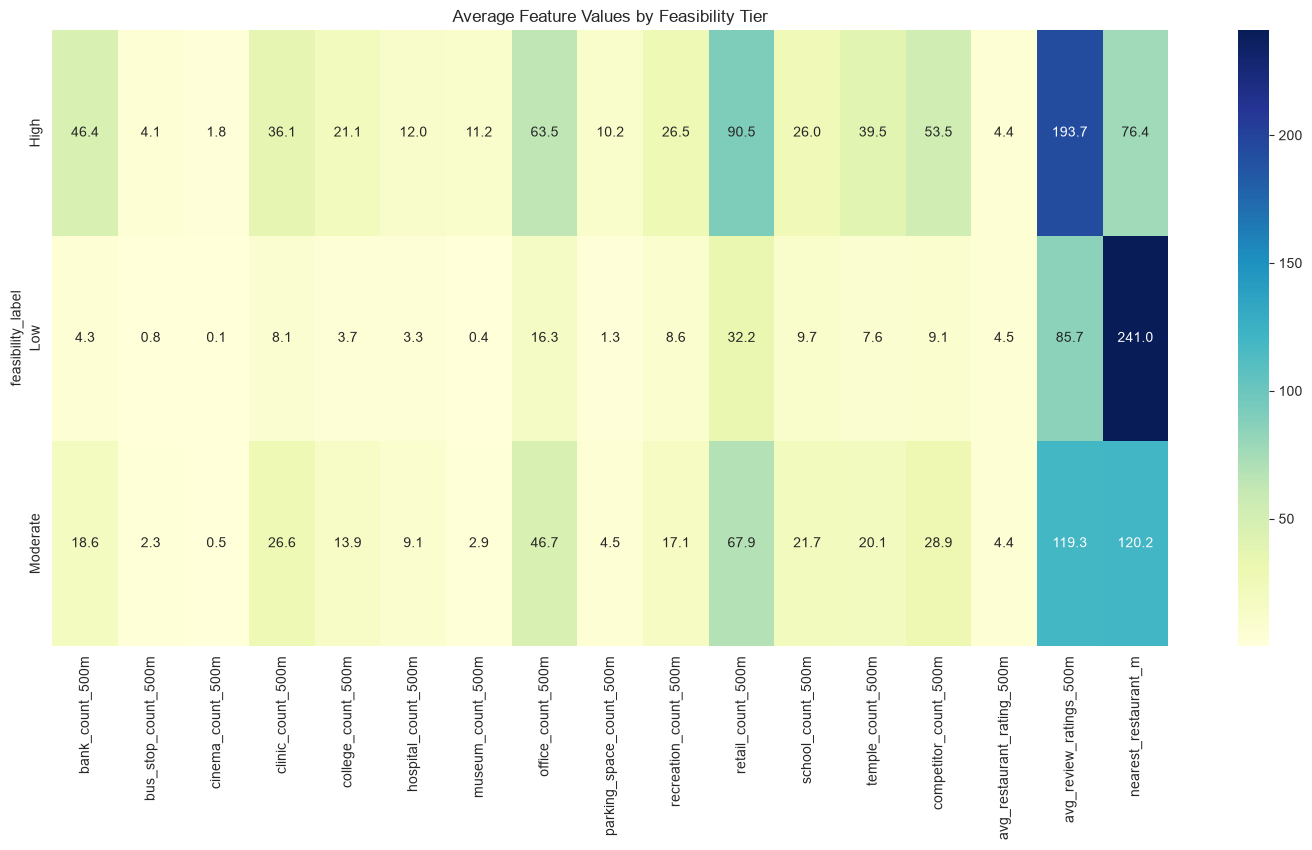

In [6]:
plt.figure(figsize=(18,8))

sns.heatmap(class_mean,
            annot=True,
            cmap="YlGnBu",
            fmt=".1f")

plt.title("Average Feature Values by Feasibility Tier")
plt.show()

### 2. Correlation Analysis

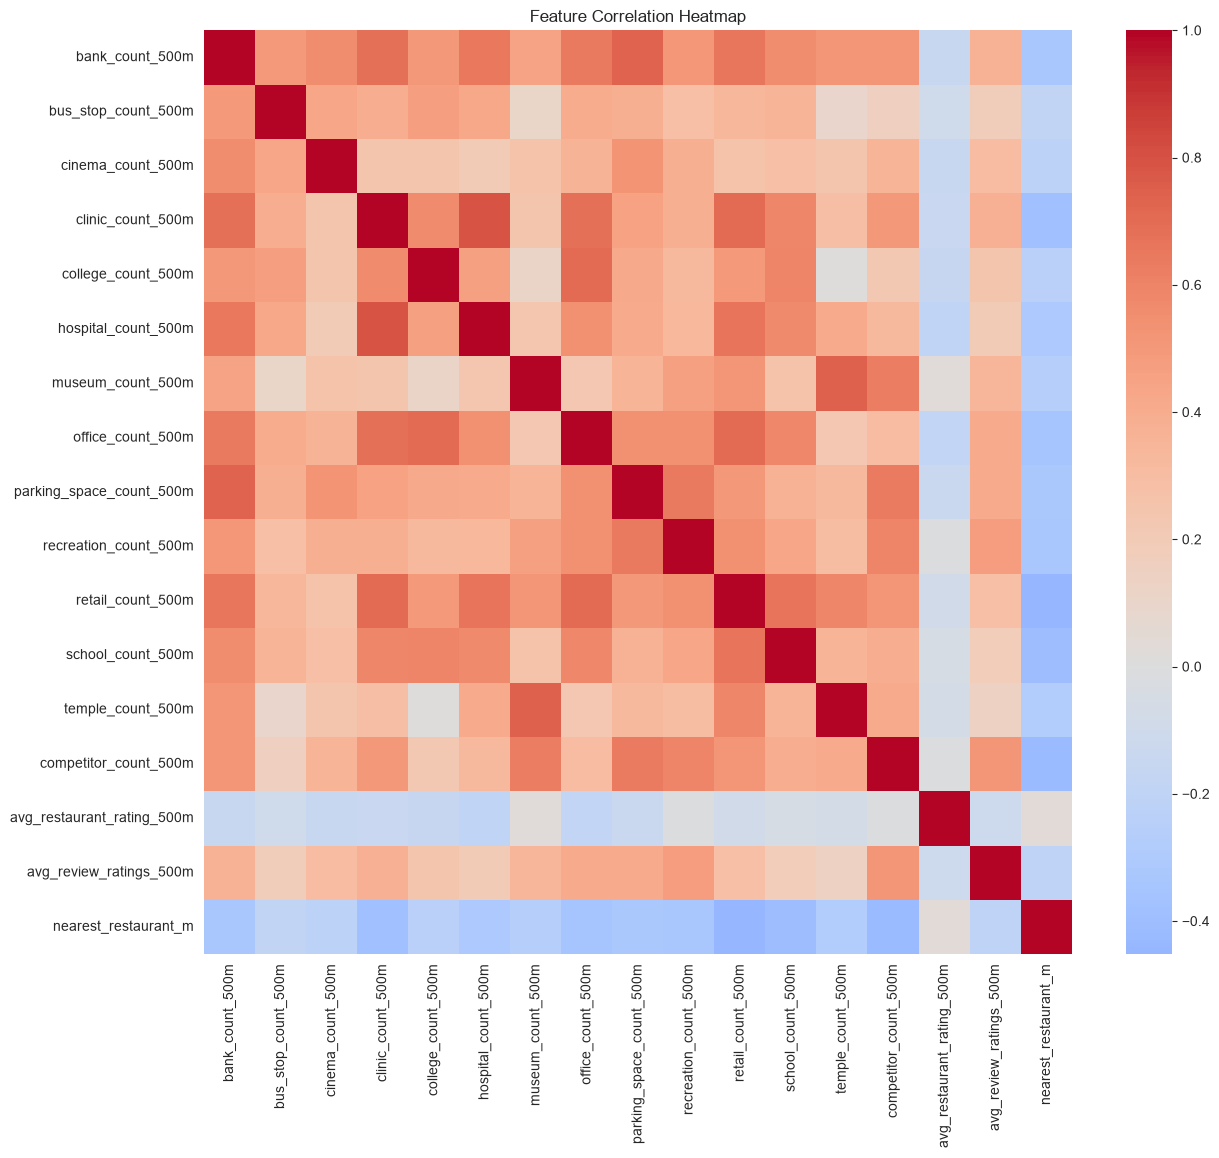

In [7]:
corr = df[FEATURES].corr()

plt.figure(figsize=(14,12))

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Heatmap")

plt.show()

### Insight:
The correlation heatmap shows that most surrounding amenity features, such as banks, schools, hospitals, offices, and retail shops, are positively correlated. This indicates that commercial and urban areas generally contain many different types of facilities together. However, these correlations are mostly moderate, meaning each feature still provides its own useful information.

The feature nearest_restaurant_m shows a negative correlation with many count-based features. This means that in areas with more surrounding facilities, restaurants are generally located closer to each other, resulting in a shorter distance to the nearest restaurant.

The avg_restaurant_rating_500m feature has very weak correlation with most other variables, suggesting that restaurant ratings are largely independent of the surrounding amenities.

Overall, the dataset does not show severe multicollinearity, as no feature pairs exhibit extremely high correlations. This indicates that most features contribute unique information and are suitable for use in the machine learning model.

#### Find Highly Correlated Pairs (>0.8)

In [14]:
corr_matrix = df[FEATURES].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0":"Feature 1",
             "level_1":"Feature 2",
             0:"Correlation"
         })
)

high_corr = high_corr[
    high_corr["Correlation"] > 0.80
].sort_values("Correlation", ascending=False)

print(high_corr)

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


### Insight :
The correlation analysis was used to detect multicollinearity among the selected features.. The Output is empty because, in dataset, no pair of features has an absolute correlation above 0.80 after removing the duplicate and self-correlations. That means there are no very strong linear relationships among the selected features.

### 3. Class Distribution by Area

feasibility_label        High  Low  Moderate
search_area                                 
Baneshwor                  95   87       350
Bhaktapur durbar square    21  304       193
Boudha stupa                0  291       220
Durbar Marg               217   53       135
Kirtipur                    0  359        66
Koteshwor                  15  249       137
New Road                  250  114       153
Patan durbar square       179  103       234
Pulchowk                   80  111       156


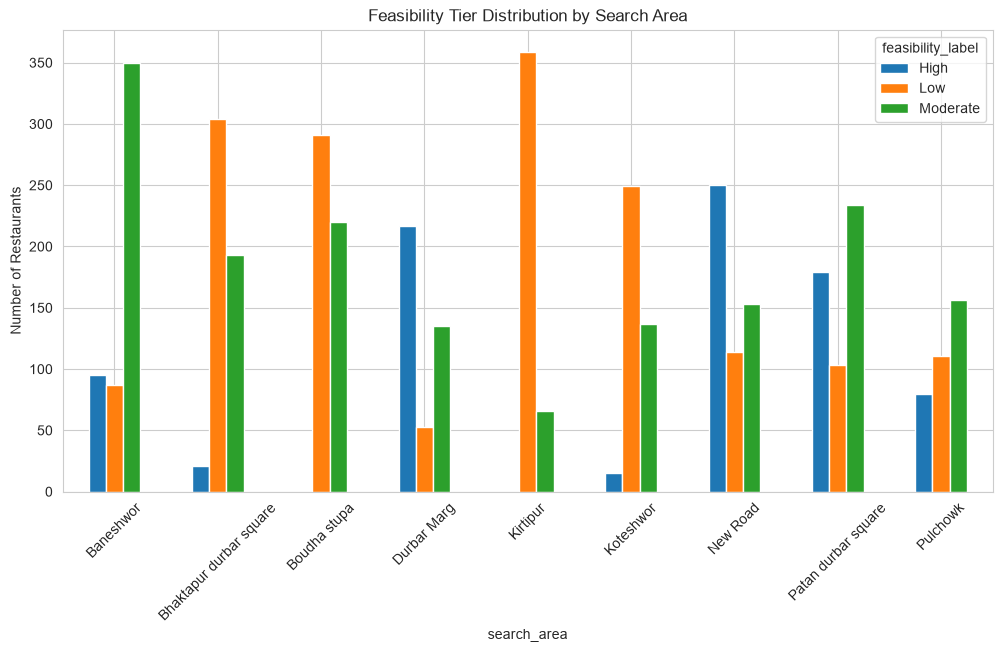

In [15]:
area_table = pd.crosstab(
    df["search_area"],
    df[TARGET]
)

print(area_table)

area_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Feasibility Tier Distribution by Search Area")

plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

### Insight :
This code is counting how many restaurants fall into each feasibility tier within each search area, then plotting those counts as a grouped bar chart

### 4. Spatial Map EDA

The spatial map EDA was performed to visualize the geographic distribution of restaurant feasibility across the study areas. By plotting each restaurant location on an interactive map and coloring the points according to feasibility tier, it becomes easier to identify whether high, moderate, and low feasibility locations are randomly distributed or spatially clustered. This step is important because location-based patterns are not always obvious from tables alone, and spatial visualization helps reveal urban hotspots and low-potential areas for restaurant placement.

In [18]:
import folium

color_map = {
    "High":"green",
    "Moderate":"blue",
    "Low":"red"
}

m = folium.Map(
    location=[
        df.latitude.mean(),
        df.longitude.mean()
    ],
    zoom_start=13
)

for _, row in df.iterrows():

    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=5,
        color=color_map.get(row[TARGET], "orange"),
        fill=True,
        fill_opacity=0.8,
        popup=f"{row['search_area']}<br>{row[TARGET]}"
    ).add_to(m)

m.save("../outputs/feasibility_map.html")


### Insight :
The output HTML map shows clear spatial variation in feasibility across the different search areas. Areas such as New Road, Durbar Marg, and Patan durbar square contain a relatively larger concentration of High-feasibility locations, suggesting stronger business potential in these zones. In contrast, areas like Kirtipur, Boudha stupa, and Bhaktapur durbar square are dominated by Low-feasibility locations, indicating weaker suitability for restaurant development. Overall, the map suggests that feasibility is strongly location-dependent, and the spatial distribution of points provides useful guidance for identifying promising restaurant sites.



### 5. Feature vs Tier Separability (Boxplots)

Feature vs tier separability is used to check whether each feature can distinguish between the feasibility tiers: Low, Moderate, and High. It is done because a useful predictive feature should show different patterns across the target classes; if the values overlap heavily for all tiers, then that feature contributes little to classification. This step is important in EDA because it helps identify which variables have real discriminatory power before building a model.

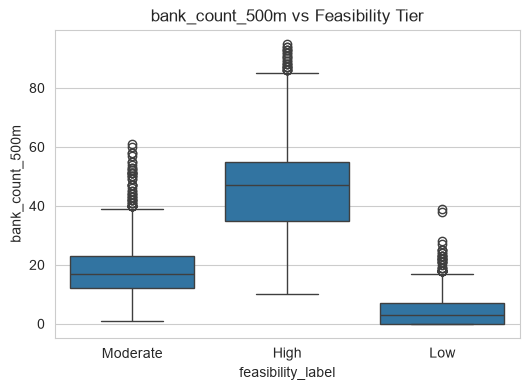

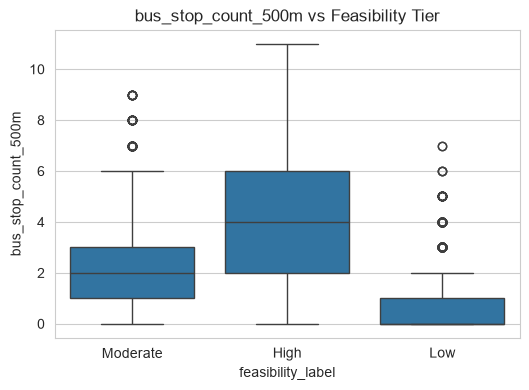

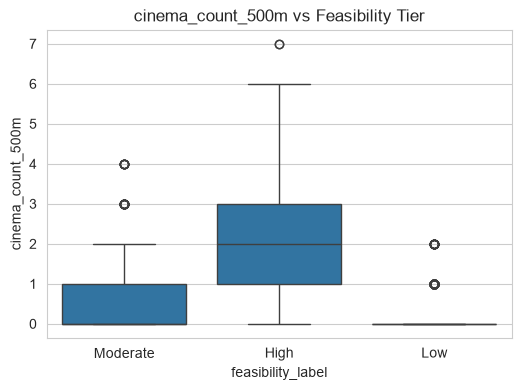

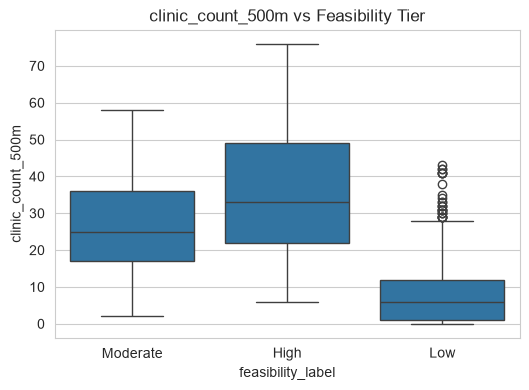

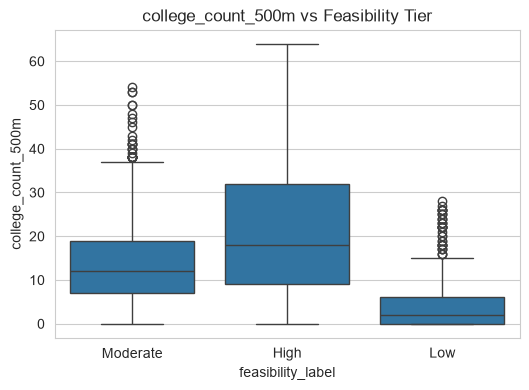

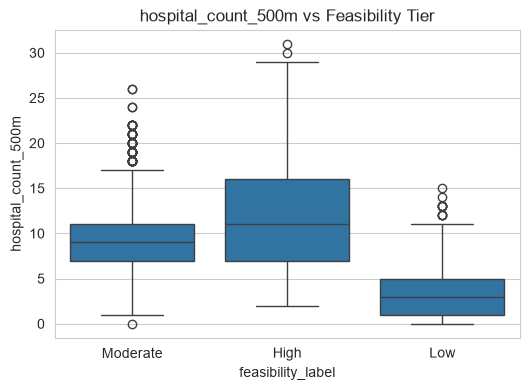

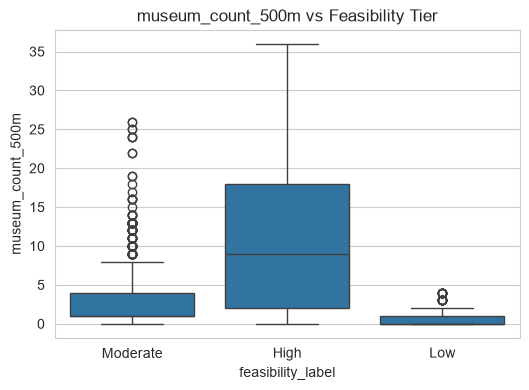

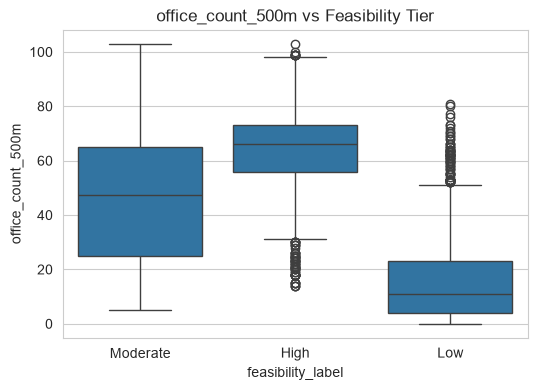

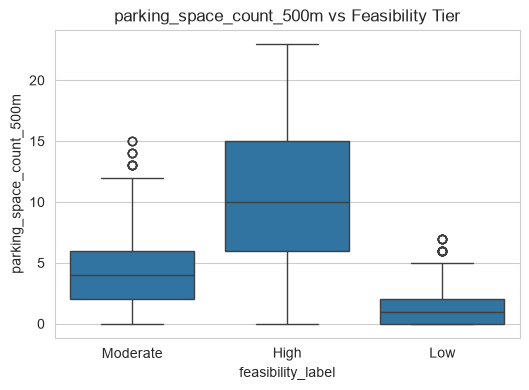

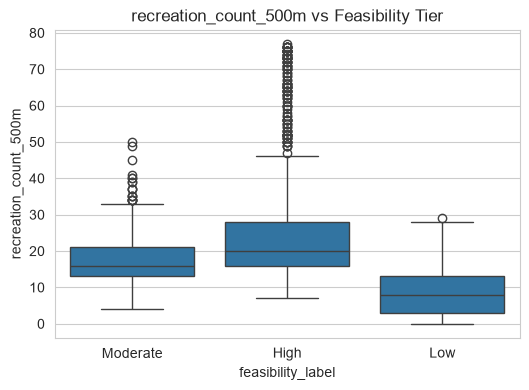

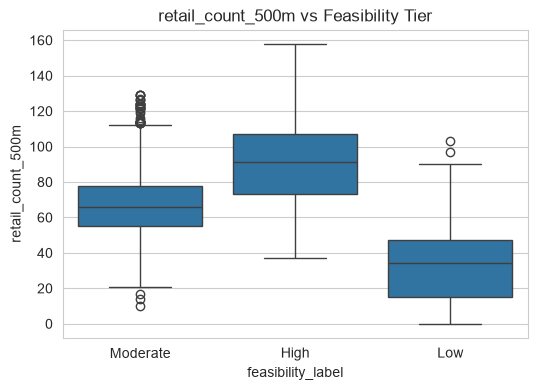

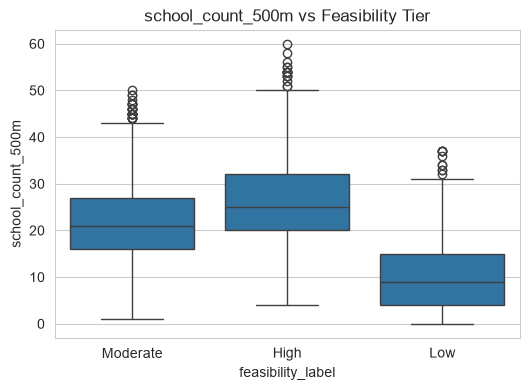

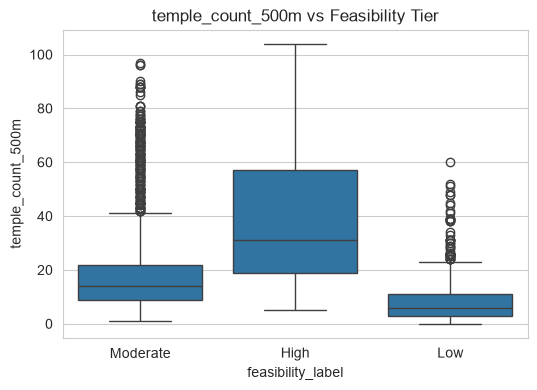

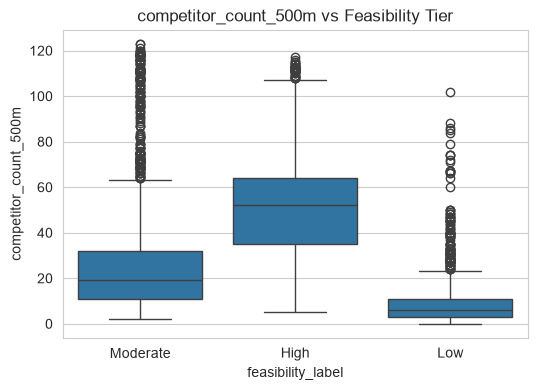

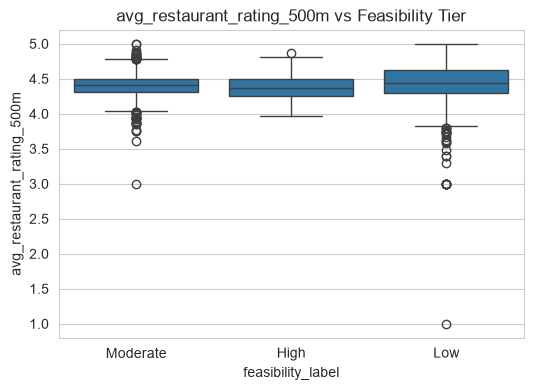

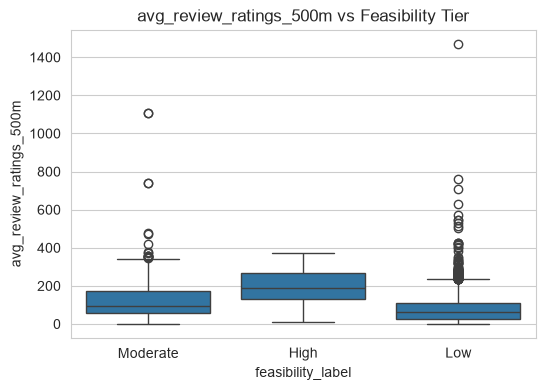

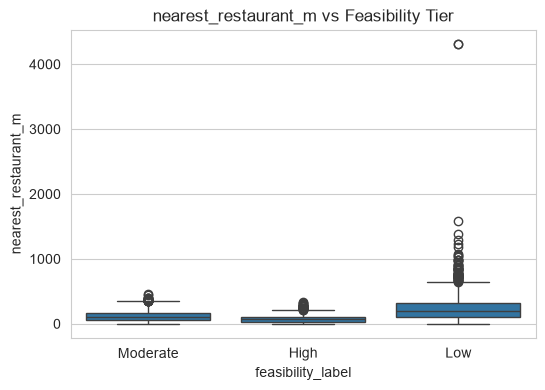

In [12]:
for feature in FEATURES:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=TARGET,
        y=feature,
        data=df
    )

    plt.title(f"{feature} vs Feasibility Tier")

    plt.show()

### Insight :
The main insight from this analysis is that some features show visible tier-wise separation while others overlap strongly. Features with clearer separation are better indicators of feasibility, while overlapping features are less useful on their own. This analysis is needed because it helps decide which features are worth keeping, how strong the target signal is, and whether the tiers are meaningfully different in feature space.

